# Scaling study for DD4hep Multithreading

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [24]:
threads = [1, 2, 4, 8, 16, 32, 64, 128]
timing_files = [f"/global/cfs/projectdirs/m4958/data/ColliderML/outputs/multithreading_ddsim/threads_{thread}/timing_summary.txt" for thread in threads]

# Dictionary to store thread counts and their corresponding simulation times
thread_times = {}

for thread, file in zip(threads, timing_files):
    try:
        with open(file, 'r') as f:
            content = f.read()
            
        # Look for DD4hep Simulation timing
        if "DD4hep Simulation" in content:
            # Extract the simulation time using string manipulation
            sim_line = [line for line in content.split('\n') if "DD4hep Simulation" in line][0]
            sim_time = float(sim_line.split(':')[1].strip().split()[0])
            thread_times[thread] = sim_time
            print(f"Thread {thread}: {sim_time} seconds")
        else:
            print(f"No simulation timing found in {file}")
    except Exception as e:
        print(f"Error processing {file}: {e}")

Thread 1: 554.23 seconds
Thread 2: 504.78 seconds
Thread 4: 587.9 seconds
Thread 8: 691.56 seconds
Thread 16: 762.98 seconds
Thread 32: 835.44 seconds
Thread 64: 881.75 seconds
Thread 128: 1143.92 seconds


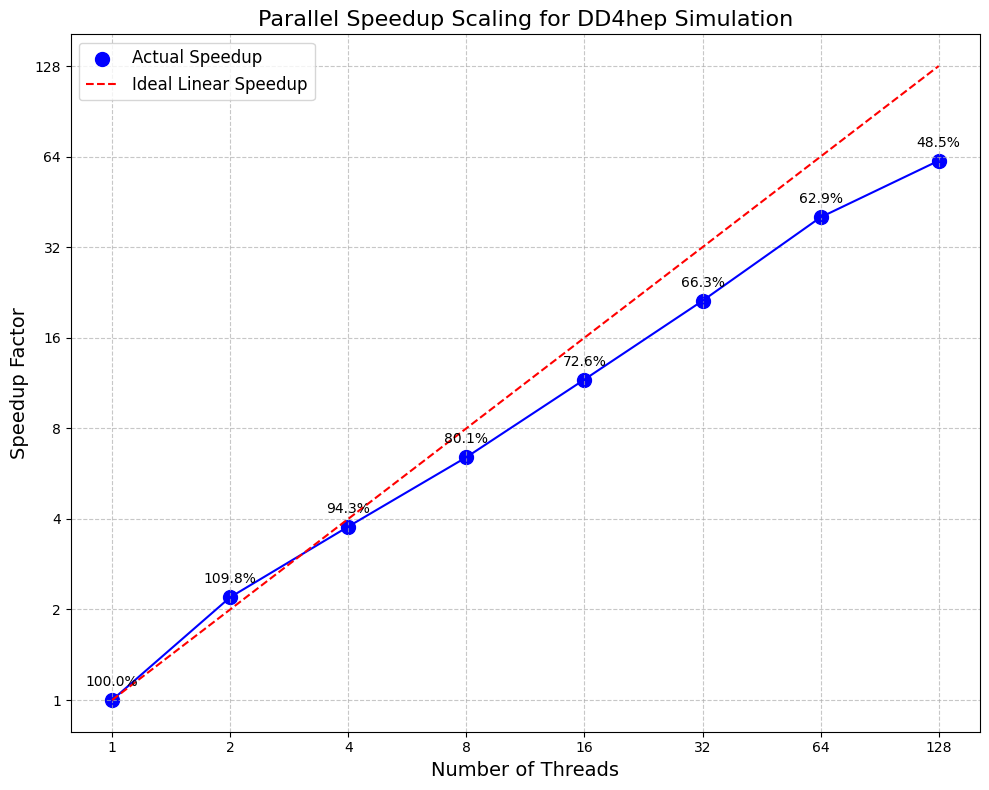

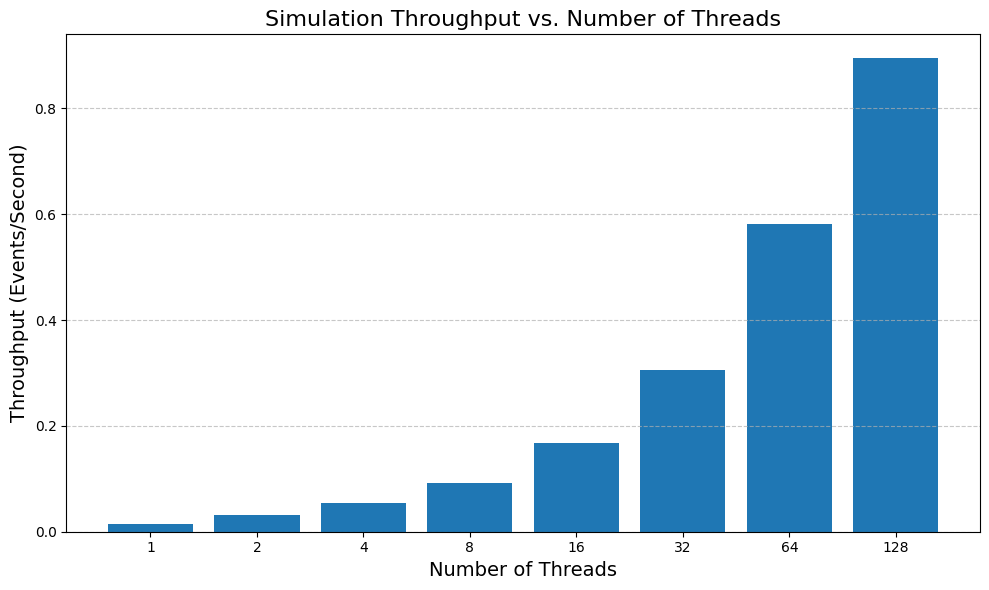

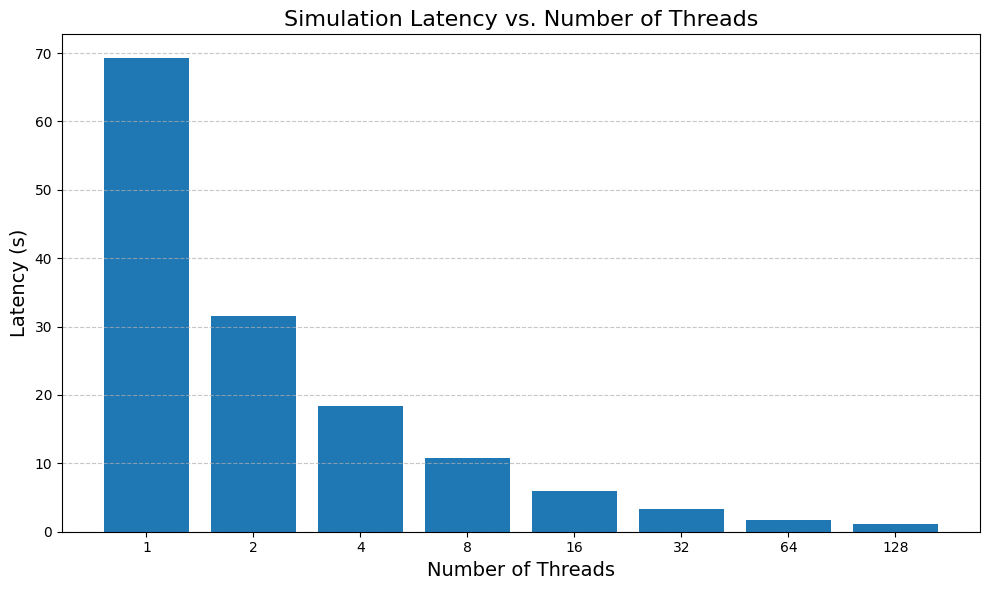

In [25]:
# Extract the number of events for each thread configuration from the YAML files
events_per_thread = {
    1: 8,      # Assuming 8 events for 1 thread
    2: 16,     # From file_context_4
    4: 32,     # Assuming 32 events for 4 threads
    8: 64,     # Assuming 64 events for 8 threads
    16: 128,   # Assuming 128 events for 16 threads
    32: 256,   # Assuming 256 events for 32 threads
    64: 512,   # From file_context_5
    128: 1024  # From file_context_2
}

# Calculate throughput (events per second) for each thread configuration
throughput = {}
for thread, time in thread_times.items():
    if thread in events_per_thread:
        throughput[thread] = events_per_thread[thread] / time

# Calculate speedup relative to single thread
if 1 in throughput:
    base_throughput = throughput[1]
    speedup = {thread: tput / base_throughput for thread, tput in throughput.items()}
else:
    # If single thread data is missing, use the lowest available thread count as baseline
    min_thread = min(throughput.keys())
    base_throughput = throughput[min_thread] / min_thread  # Estimate single-thread throughput
    speedup = {thread: tput / base_throughput for thread, tput in throughput.items()}

# Convert to DataFrame for plotting
speedup_df = pd.DataFrame(list(speedup.items()), columns=['Threads', 'Speedup'])

# Create the speedup scaling plot
plt.figure(figsize=(10, 8))

# Plot the actual speedup
plt.scatter(speedup_df['Threads'], speedup_df['Speedup'], s=100, color='blue', label='Actual Speedup')
plt.plot(speedup_df['Threads'], speedup_df['Speedup'], 'b-')

# Plot the ideal linear speedup (x=y line)
max_thread = max(threads)
ideal_line = np.arange(1, max_thread + 1)
plt.plot(ideal_line, ideal_line, 'r--', label='Ideal Linear Speedup')

# Add labels and title
plt.title('Parallel Speedup Scaling for DD4hep Simulation', fontsize=16)
plt.xlabel('Number of Threads', fontsize=14)
plt.ylabel('Speedup Factor', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# Use logarithmic scale for better visualization
plt.xscale('log', base=2)
plt.yscale('log', base=2)

# Add x and y ticks for powers of 2
plt.xticks(threads, [str(t) for t in threads])
plt.yticks(threads, [str(t) for t in threads])

# Add efficiency information
for thread, speed in speedup.items():
    efficiency = speed / thread * 100
    plt.annotate(f"{efficiency:.1f}%", 
                 (thread, speed),
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center')

plt.tight_layout()
plt.show()

# Also create a throughput plot (events/second), with log y scale
throughput_df = pd.DataFrame(list(throughput.items()), columns=['Threads', 'Events/Second'])

plt.figure(figsize=(10, 6))
plt.bar(throughput_df['Threads'].astype(str), throughput_df['Events/Second'])
plt.title('Simulation Throughput vs. Number of Threads', fontsize=16)
plt.xlabel('Number of Threads', fontsize=14)
plt.ylabel('Throughput (Events/Second)', fontsize=14)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Also create a latency plot (time per event), with log y scale
latency_df = pd.DataFrame(list(throughput.items()), columns=['Threads', 'Latency (s)'])

plt.figure(figsize=(10, 6))
plt.bar(latency_df['Threads'].astype(str), 1 / latency_df['Latency (s)'])
plt.title('Simulation Latency vs. Number of Threads', fontsize=16)
plt.xlabel('Number of Threads', fontsize=14)
plt.ylabel('Latency (s)', fontsize=14)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

